In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import umap

import pyLDAvis
import pyLDAvis.gensim_models as gensim_models

from gensim.models import LdaMulticore, CoherenceModel
from gensim.corpora import Dictionary

from rital_nlp_project.common.utils import load_clean_data
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.presidents.utils import concat_seq_by_class

init_notebook()

### Movies

In [2]:
texts_movies, classes_movies = load_clean_data("../Dataset/movies_clean.parquet")

In [3]:
texts_tokens = [text.split() for text in texts_movies]

# dictionary: maps each word to a unique integer ID
dictionary = Dictionary(texts_tokens)

# filter extremes
dictionary.filter_extremes(no_below=10, no_above=0.50)

# bag-of-words corpus: each doc = list of (word_id, count) tuples
corpus = [dictionary.doc2bow(doc) for doc in texts_tokens]

In [4]:
params = {
    "n_topics" : [2, 3, 5, 10, 15, 20],
    "perplexity" : [],
    "c_v" : []
}

for k in params["n_topics"]:
    lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=k, passes=10, random_state=42, chunksize=100, per_word_topics=True)
    coherence_model = CoherenceModel(model=lda_model, texts=texts_tokens, dictionary=dictionary, coherence='c_v')
    params["perplexity"].append(lda_model.log_perplexity(corpus))
    c_v = coherence_model.get_coherence()
    print(k, c_v)
    params["c_v"].append(coherence_model.get_coherence())

2 0.26031181389580815


Process SpawnPoolWorker-17:
Process SpawnPoolWorker-16:
Process SpawnPoolWorker-15:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/bsh2022/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/bsh2022/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/bsh2022/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/multiprocessing/pool.py", line 109, in worker
    initializer(*initargs)
    ~~~~~~~~~~~^^^^^^^^^^^
  File "/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/gensim/models/ldamulticore.py", line 341, in worker_e_step
    chunk_no, chunk, w_state = input_queue.ge

KeyboardInterrupt: 

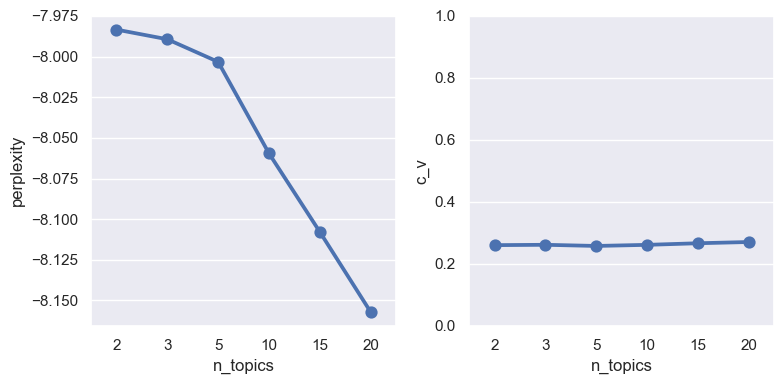

In [35]:
df = pd.DataFrame(data=params)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

sns.pointplot(data=df, x="n_topics", y="perplexity", ax=ax1)
sns.pointplot(data=df, x="n_topics", y="c_v", ax=ax2)
ax2.set_ylim(0, 1)

plt.tight_layout()

**Notes**

- Coherence score is very low ***(why?)*** -> visual inspection. The goal is to avoid many overlapping circles
- TODO : ***salient terms?***

In [5]:
lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=5, passes=10, random_state=42, chunksize=100, per_word_topics=True)
pyLDAvis.enable_notebook(local=True)
vis = gensim_models.prepare(lda_model, corpus, dictionary)

pyLDAvis.display(vis)

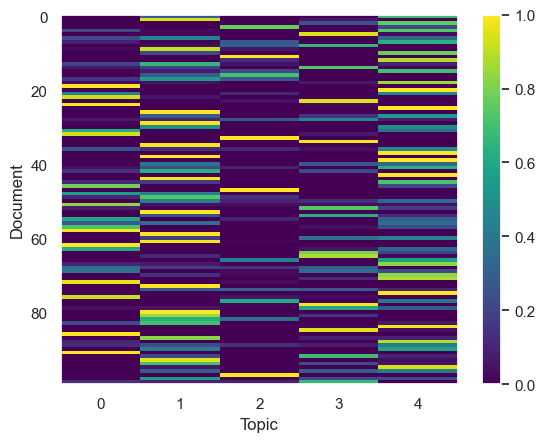

In [ ]:
doc_topic_matrix = np.array([[prob for _, prob in lda_model.get_document_topics(bow, minimum_probability=0)]
                              for bow in corpus])

limit = 100
plt.imshow(doc_topics_matrix[:limit, :], aspect="auto", vmin=0, vmax=1, cmap="viridis")
plt.xlabel("Topic")
plt.ylabel(f"Document (top {limit})")
plt.colorbar()
plt.grid(False)

In [22]:
dominant_topics = doc_topic_matrix.argmax(axis=1)
umap_ = umap.UMAP(n_components=2, random_state=42, metric="hellinger")
doc_topics_matrix_reduced = umap_.fit_transform(doc_topic_matrix)

/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


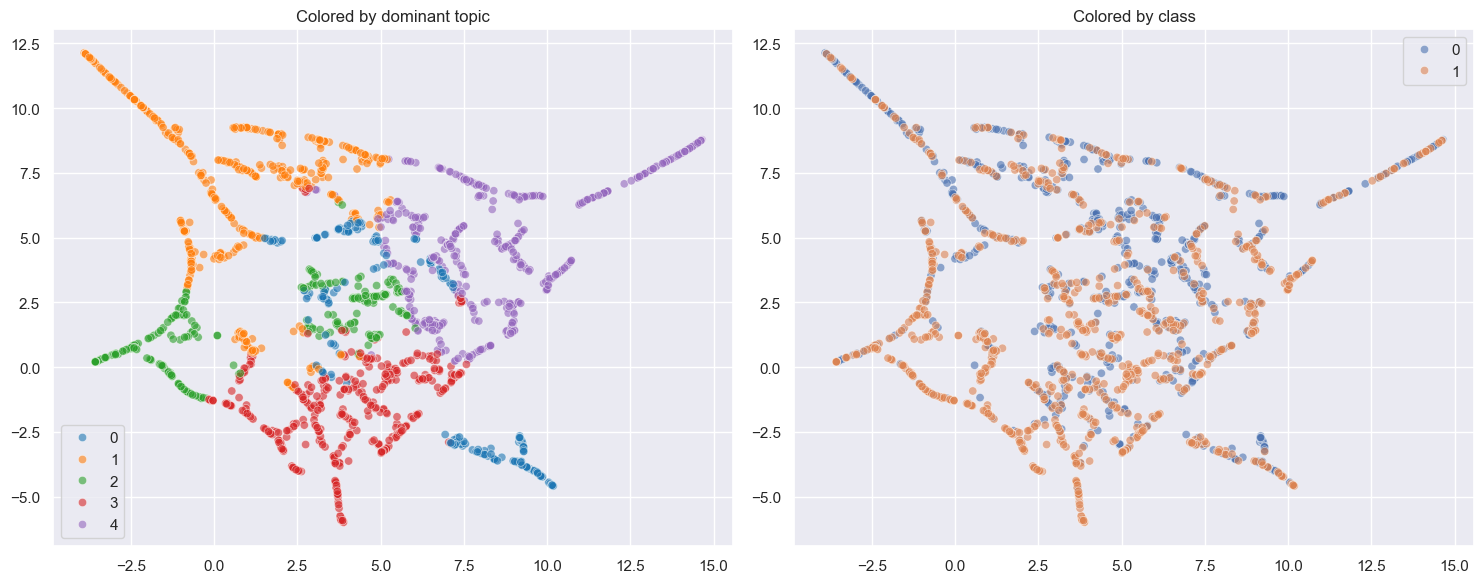

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.set_title("Colored by dominant topic")
sns.scatterplot(
    x=doc_topics_matrix_reduced[:, 0],
    y=doc_topics_matrix_reduced[:, 1],
    hue=dominant_topics,
    palette="tab10",       
    alpha=0.6,
    ax=ax1
)
ax2.set_title("Colored by class")
sns.scatterplot(
    x=doc_topics_matrix_reduced[:, 0],
    y=doc_topics_matrix_reduced[:, 1],
    hue=classes_movies,       
    alpha=0.6,
    ax=ax2
)

plt.tight_layout()

### Presidents

**Notes**

- LDA struggles with very short documents (the case here, since very likely the whole docs were cut into phrases). Indeed, if LDA (e.g. 5 topics) is examined on `texts_pres`, topics are hard to interpret. However, if LDA is run on `texts_pres_concat` (much longer documents), topics are much more meaningful

- **To test** : since for predictions topics would be inferred per phrase , check if performance is ok

In [22]:
texts_pres, classes_pres = load_clean_data("../Dataset/presidents_clean.parquet")
texts_pres_concat, classes_pres_concat = concat_seq_by_class(texts_pres, classes_pres)

#### LDA on `texts_pres`
Best coherence score around 0.45, for `n_topics=3` or `n_topics=5`

In [24]:
texts_tokens = [text.split() for text in texts_pres]
dictionary = Dictionary(texts_tokens)
dictionary.filter_extremes(no_below=10, no_above=0.50)
corpus = [dictionary.doc2bow(doc) for doc in texts_tokens]

lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=5, passes=10, random_state=42, chunksize=50, per_word_topics=True)
pyLDAvis.enable_notebook(local=True)
vis = gensim_models.prepare(lda_model, corpus, dictionary)

pyLDAvis.display(vis)

#### LDA on `texts_pres_concat`

In [96]:
texts_tokens = [text.split() for text in texts_pres_concat]
dictionary = Dictionary(texts_tokens)
dictionary.filter_extremes(no_below=10, no_above=0.50)
corpus = [dictionary.doc2bow(doc) for doc in texts_tokens]

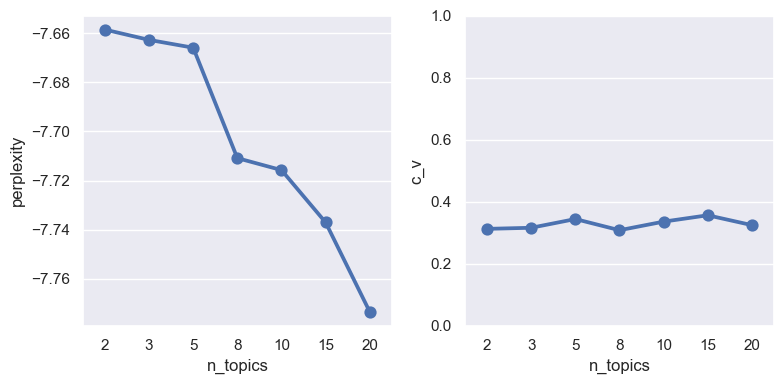

In [28]:
params = {
    "n_topics" : [2, 3, 5, 8, 10, 15, 20],
    "perplexity" : [],
    "c_v" : []
}

for k in params["n_topics"]:
    lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=k, passes=10, random_state=42, chunksize=100, per_word_topics=True)
    coherence_model = CoherenceModel(model=lda_model, texts=texts_tokens, dictionary=dictionary, coherence='c_v')
    params["perplexity"].append(lda_model.log_perplexity(corpus))
    c_v = coherence_model.get_coherence()
    params["c_v"].append(coherence_model.get_coherence())

df = pd.DataFrame(data=params)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

sns.pointplot(data=df, x="n_topics", y="perplexity", ax=ax1)
sns.pointplot(data=df, x="n_topics", y="c_v", ax=ax2)
ax2.set_ylim(0, 1)

plt.tight_layout()

In [32]:
lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=8, passes=10, random_state=42, chunksize=100, per_word_topics=True)
pyLDAvis.enable_notebook(local=True)
vis = gensim_models.prepare(lda_model, corpus, dictionary)

pyLDAvis.display(vis)

#### UMAP on concatenated phrases

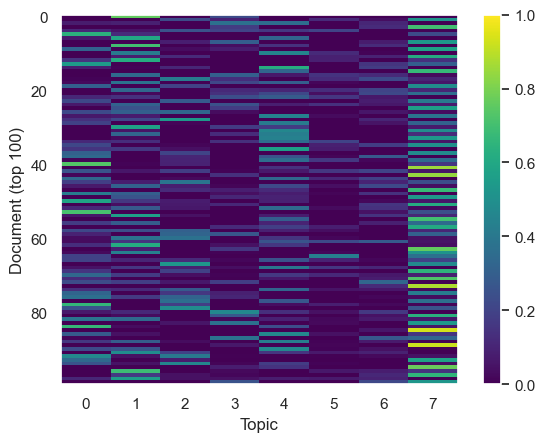

In [101]:
doc_topic_matrix = np.array([[prob for _, prob in lda_model.get_document_topics(bow, minimum_probability=0)]
                              for bow in corpus])

limit = 100
plt.imshow(doc_topic_matrix[:limit, :], aspect="auto", vmin=0, vmax=1, cmap="viridis")
plt.xlabel("Topic")
plt.ylabel(f"Document (top {limit})")
plt.colorbar()
plt.grid(False)

In [108]:
dominant_topics = doc_topic_matrix.argmax(axis=1)

# Warning : a known upstream issue in UMAP's Hellinger implementation with numba (not fully fixed yet)
umap_ = umap.UMAP(n_components=2, random_state=42, metric="hellinger")
embedding = umap_.fit_transform(doc_topic_matrix)

/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


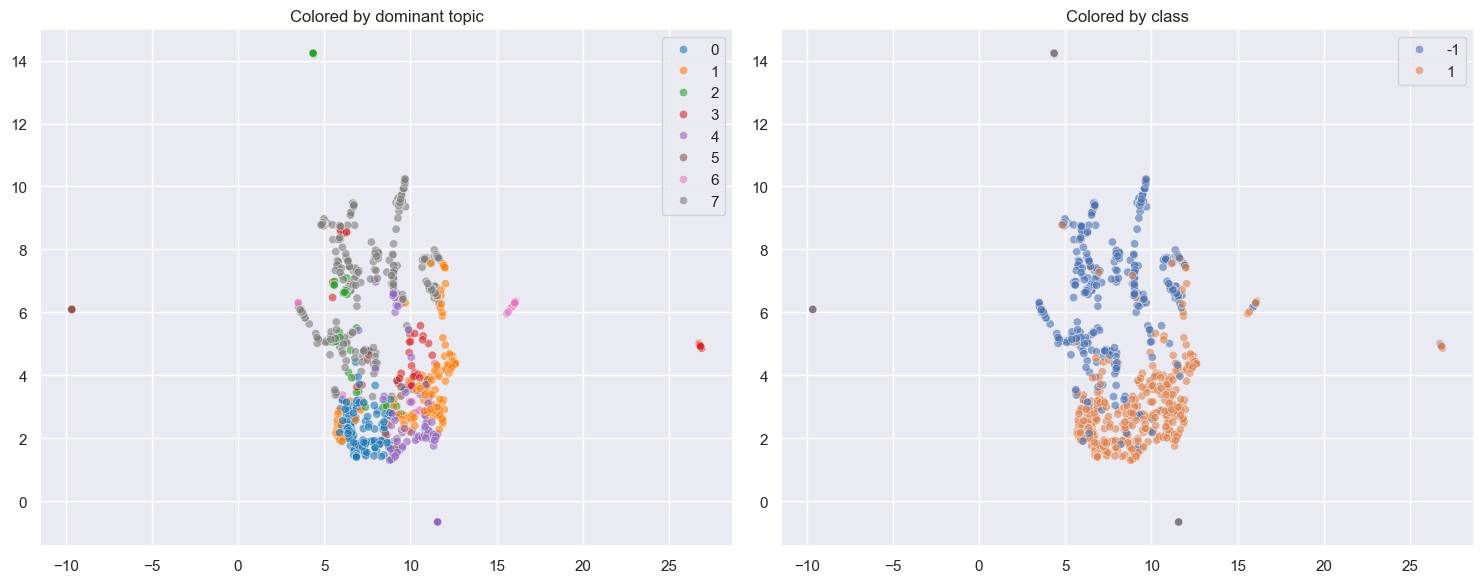

In [111]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.set_title("Colored by dominant topic")
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=dominant_topics[:],
    palette="tab10",       
    alpha=0.6,
    ax=ax1
)
ax2.set_title("Colored by class")
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=classes_pres_concat[:],    
    palette="deep",
    alpha=0.6,
    ax=ax2
)

plt.tight_layout()

##### UMAP on separated phrases

In [118]:
texts_tokens = [text.split() for text in texts_pres]
corpus = [dictionary.doc2bow(doc) for doc in texts_tokens]
doc_topic_matrix = np.array([[prob for _, prob in lda_model.get_document_topics(bow, minimum_probability=0)]
                              for bow in corpus])

proba_max = doc_topic_matrix.max(axis=1)
mask = proba_max > 0.9  # only keep documents with clear dominant topic (to reduce 50k points to 10k)
subset = doc_topic_matrix[mask]
dominant_topics = subset.argmax(axis=1)

In [124]:
umap_ = umap.UMAP(n_components=2, random_state=42, metric="hellinger")
embedding = umap_.fit_transform(subset)

/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: invalid value encountered in correct_alternative_hellinger
  return super().__call__(*args, **kws)


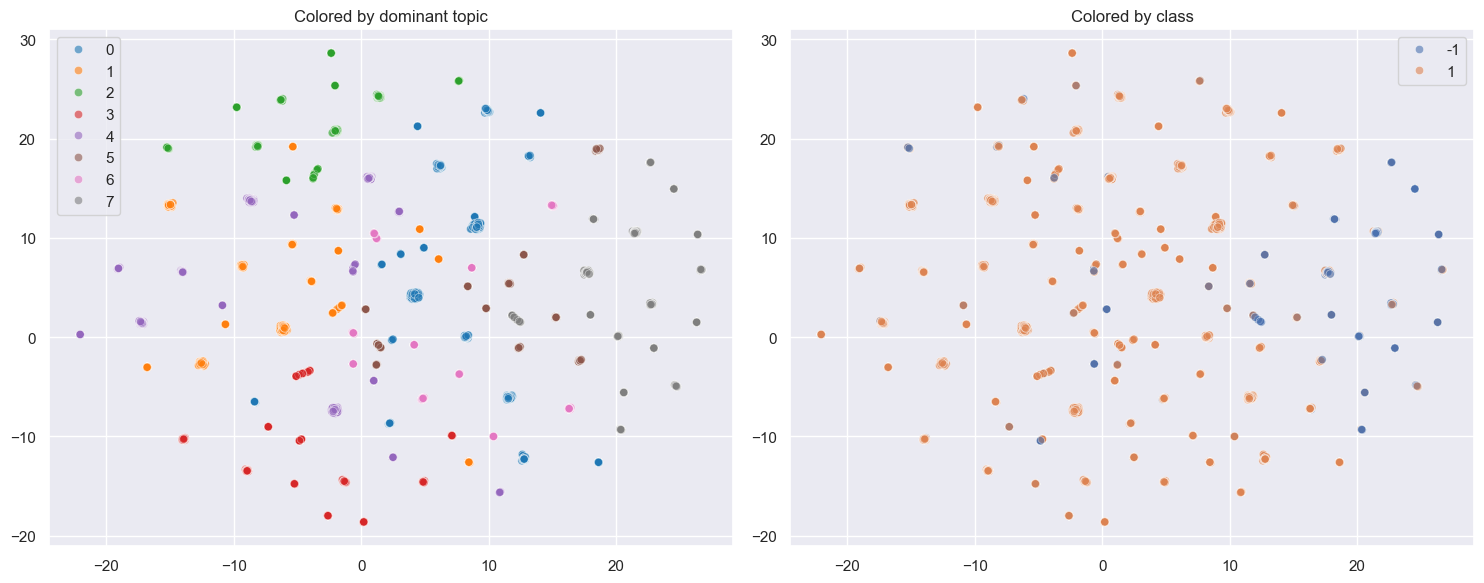

In [125]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.set_title("Colored by dominant topic")
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=dominant_topics,
    palette="tab10",       
    alpha=0.6,
    ax=ax1
)
ax2.set_title("Colored by class")
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=classes_pres[mask],    
    palette="deep",
    alpha=0.6,
    ax=ax2
)

plt.tight_layout()